# Member 3 - Random Forest Model

This notebook presents Member 3's machine learning model for the Obesity Levels dataset.

## Objective
The goal of this model is to predict the obesity category (`NObeyesdad`) using a Random Forest Classifier.

## Why Random Forest?
Random Forest is a strong ensemble learning model that often performs well on tabular classification datasets. It can also provide feature importance scores, which helps explain which features contribute most to the predictions.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.pipeline import Pipeline

## 1. Load the dataset

In this step, we load the Obesity dataset from the shared `data/raw` folder.
We also create a `results` folder so that plots can be saved there.

In [2]:
# Get current working directory (works well inside notebook)
script_dir = os.getcwd()

# Update this path if your notebook is in a different folder
data_path = os.path.abspath(os.path.join(script_dir, "../../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv"))
results_dir = os.path.abspath(os.path.join(script_dir, "../../results"))

os.makedirs(results_dir, exist_ok=True)

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Encode categorical features and target labels

The dataset contains several categorical columns stored as text.
Machine learning models such as Random Forest require numeric input, so we encode these text values into numbers.

We also use a separate encoder for the target column so that predictions can later be interpreted using the original class names.

In [3]:
# Make a copy so we do not accidentally overwrite the original data
df_encoded = df.copy()

categorical_cols = [
    'Gender', 'family_history_with_overweight', 'FAVC',
    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'
]

# Encode input categorical columns
feature_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
    feature_encoders[col] = encoder

# Separate encoder for target column
target_encoder = LabelEncoder()
df_encoded['NObeyesdad'] = target_encoder.fit_transform(df_encoded['NObeyesdad'])

print("Categorical columns encoded successfully.")
print("Target classes:", list(target_encoder.classes_))
df_encoded.head()

Categorical columns encoded successfully.
Target classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


## 3. Split features and target

We separate the input features (`X`) from the target label (`y`), then split the data into training and test sets.

A stratified split is used so that the class distribution remains balanced in both sets.

In [4]:
X = df_encoded.drop(columns=['NObeyesdad'])
y = df_encoded['NObeyesdad']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1688, 16)
Test set shape: (423, 16)


## 4. Train the baseline Random Forest model

We first train a baseline Random Forest model using fixed parameters.
This helps us understand the initial performance before hyperparameter tuning.## 4. Train the baseline Random Forest model

We first train a baseline Random Forest model using fixed parameters.
This helps us understand the initial performance before hyperparameter tuning.

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-2
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 5. Evaluate training and test accuracy

Training accuracy helps us understand how well the model fits the training data.
Test accuracy shows how well the model generalizes to unseen data.

In [6]:
# Training performance
y_train_pred = rf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Test performance
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")

Train Accuracy: 1.0000
Test Accuracy:  0.9433


## 6. Detailed classification metrics

Accuracy alone is not always enough.
We also calculate weighted precision, recall, and F1-score to better evaluate the model across multiple classes.

In [7]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Detailed Test Metrics")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Detailed Test Metrics
Precision: 0.9474
Recall:    0.9433
F1-score:  0.9441


## 7. Classification report

This report shows the precision, recall, and F1-score for each individual obesity class.

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.81      0.95      0.87        58
     Obesity_Type_I       0.93      0.97      0.95        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.86      0.88        58
Overweight_Level_II       0.98      0.91      0.95        58

           accuracy                           0.94       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.94      0.94       423



## 8. Confusion matrix

The confusion matrix helps us see which classes are predicted correctly and which classes are confused with one another.

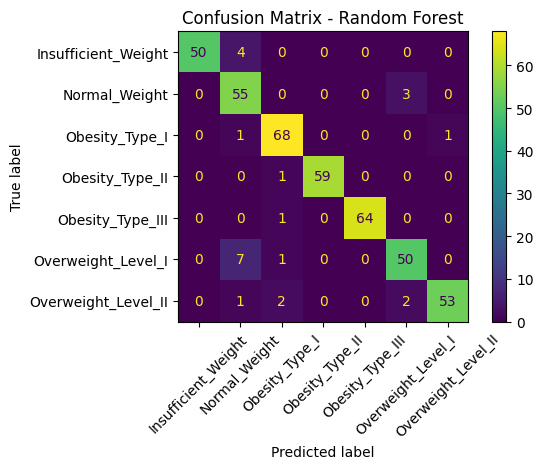

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "member3_confusion_matrix.png"), dpi=150)
plt.show()

## 9. Cross-validation

To obtain a more reliable estimate of model performance, we perform 5-fold stratified cross-validation on the training data.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')

print("Cross-validation accuracy scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-validation accuracy scores: [0.95266272 0.95266272 0.93786982 0.94065282 0.92284866]
Mean CV Accuracy: 0.9413
Standard Deviation: 0.0111


## 10. Feature importance

Random Forest provides feature importance values, which can help identify which features are most useful in predicting the target class.

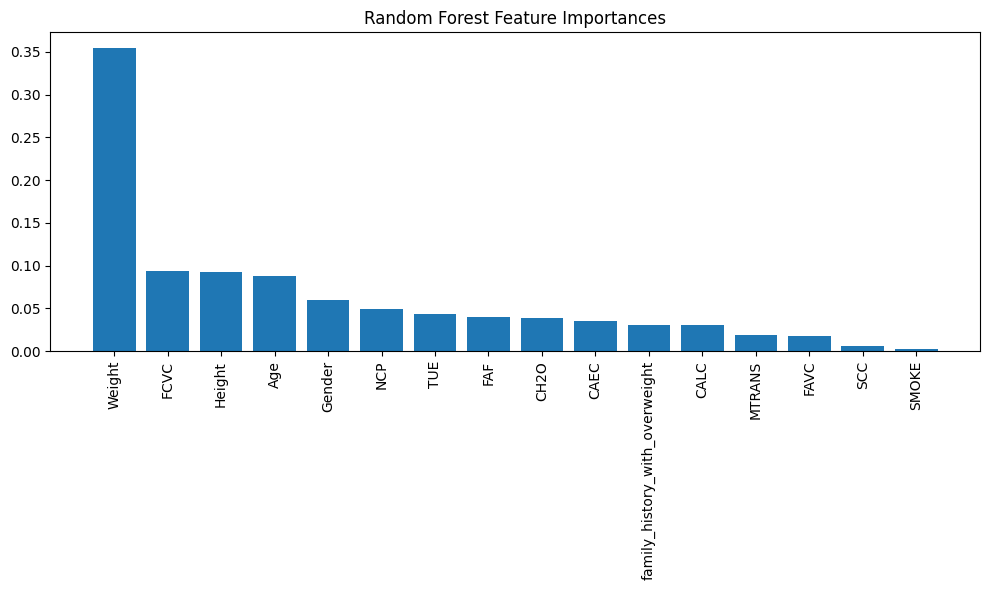

In [11]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "member3_feature_importance.png"), dpi=150)
plt.show()

## 11. Multi-class ROC curves

Because this is a multi-class classification problem, we use a one-vs-rest approach to generate ROC curves for each class.

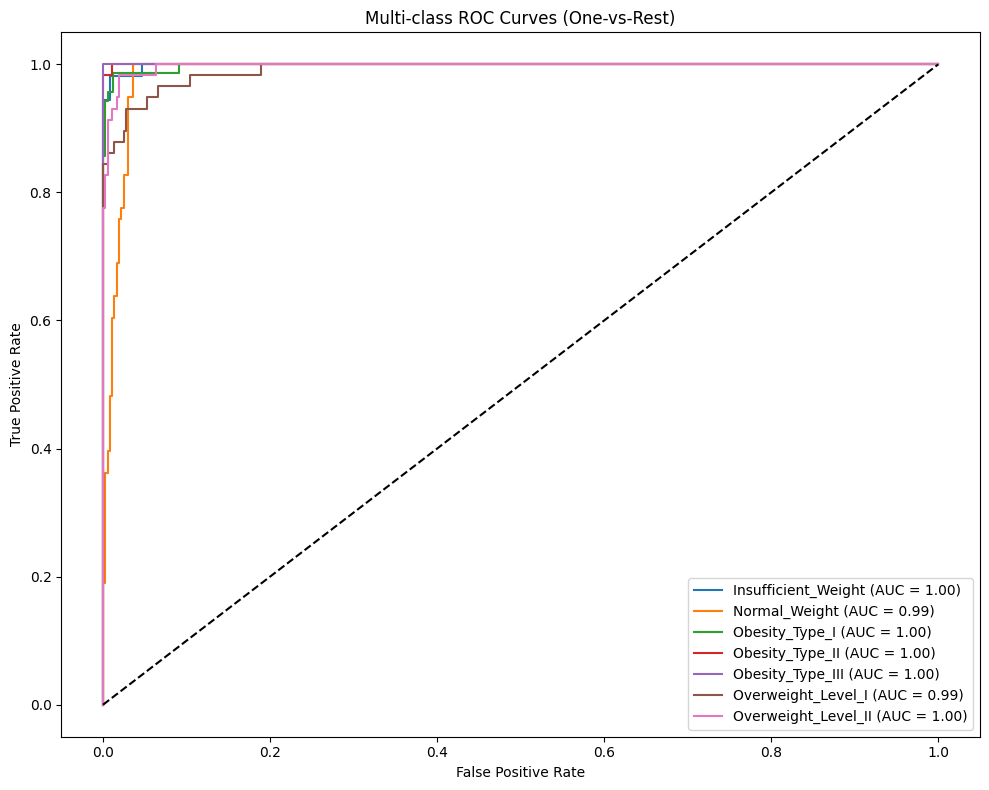

In [12]:
y_test_bin = label_binarize(y_test, classes=range(len(target_encoder.classes_)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{target_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "member3_roc_curve.png"), dpi=150)
plt.show()

## 12. Hyperparameter tuning with GridSearchCV

To improve the model, we tune selected Random Forest parameters using GridSearchCV.
This helps us find the best combination of parameters based on cross-validation accuracy.

In [13]:
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, None]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 200}
Best CV Accuracy: 0.9508


## 13. Evaluate the tuned model on the test set

After tuning, we test the best model on the held-out test set to compare its performance with the baseline model.

In [14]:
best_model = grid_search.best_estimator_
best_y_pred = best_model.predict(X_test)

best_test_accuracy = accuracy_score(y_test, best_y_pred)

print(f"Tuned Model Test Accuracy: {best_test_accuracy:.4f}")

Tuned Model Test Accuracy: 0.9574


## 14. Final conclusion

The Random Forest model performed well on the Obesity dataset and provided strong classification results.
It also offered useful feature importance information, which helps explain the model.

### Summary
- A baseline Random Forest model was trained and evaluated
- Multiple classification metrics were calculated
- Cross-validation was performed for more reliable performance estimation
- Feature importance and ROC curves were visualized
- Hyperparameter tuning was applied using GridSearchCV

This model can now be compared fairly with the other members' models.